In [5]:
pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.0 MB/s eta 0:00:00


   Student_ID                  Name  Gender Department  Year  Maths  Science  \
0           2           David Jones    Male        CSE     1     57       49   
1           4  Katherine Garner DVM  Female        ECE     2     43       76   
2           5       Michael Johnson  Female        ECE     3     56       81   
3           4          John Johnson  Female         IT     2     96       65   
4           4       Elizabeth Young    Male        CSE     4     48       81   

   English  Attendance  Internal_Marks  External_Marks  
0       85          76              22              62  
1       82          91              13              73  
2       88          74              17              74  
3       70          66              19              68  
4       79          56               0              60  
Mean: 29.942
Median: 29.0
Mode: 28.5
Standard Deviation: 8.36117653756751
Empty DataFrame
Columns: [Student_ID, Name, Gender, Department, Year, Maths, Science, English, Attendan

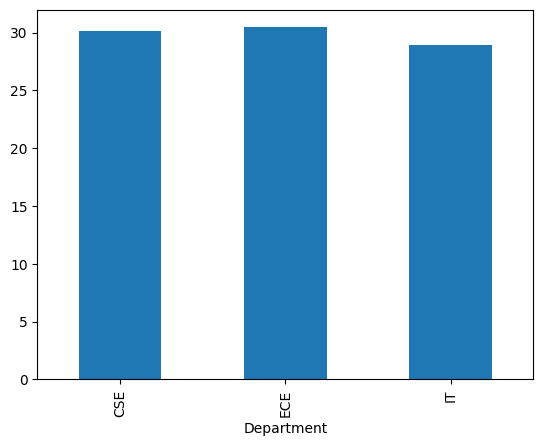

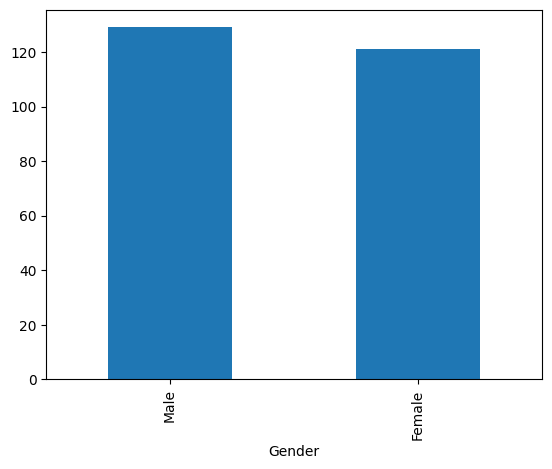

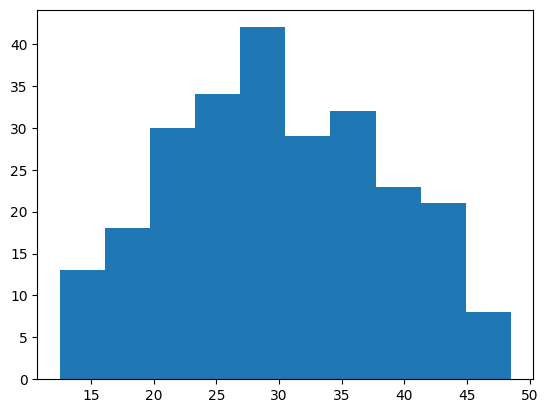

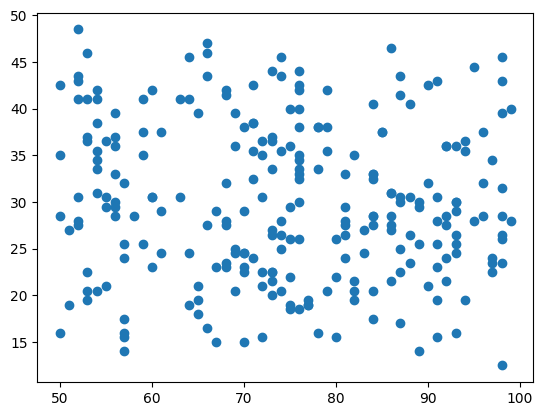

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from faker import Faker

fake=Faker()

data={"Student_ID":np.random.randint(0,10,250),
"Name":[fake.name() for _ in range(250)],
"Gender":np.random.choice(["Male","Female"],250),
"Department":np.random.choice(["CSE","IT","ECE"],250),
"Year":np.random.choice([1,2,3,4],250),
"Maths":np.random.randint(40,100,250),
"Science":np.random.randint(40,100,250),
"English":np.random.randint(40,100,250),
"Attendance":np.random.randint(50,100,250),
"Internal_Marks":np.random.randint(0,25,250),
"External_Marks":np.random.randint(25,75,250)}

df=pd.DataFrame(data)

print(df.head())

df["Total"]=df["Internal_Marks"]+df["External_Marks"]
df["Average"]=df["Total"]/2

def grade(marks):
    if marks>=90:return"A"
    elif marks>=75:return"B"
    elif marks>=50:return"C"
    else:return"Fail"

df["Grade"]=df["Average"].apply(grade)

print("Mean:",df["Average"].mean())
print("Median:",df["Average"].median())
print("Mode:",df["Average"].mode()[0])
print("Standard Deviation:",df["Average"].std())

top_students=df[df["Average"]>=90]
fail_students=df[df["Grade"]=="Fail"]

print(top_students)
print(fail_students)

print(df.groupby("Department")["Average"].mean())
print(df.groupby("Gender")["Average"].mean())
print(df.groupby("Year")["Average"].mean())

print(df[["Attendance","Average"]].corr())

df.groupby("Department")["Average"].mean().plot(kind='bar')
plt.show()

df["Gender"].value_counts().plot(kind='bar')
plt.show()

plt.hist(df["Average"])
plt.show()

plt.scatter(df["Attendance"],df["Average"])
plt.show()
